<a href="https://colab.research.google.com/github/sidneyppratt-svg/credit-spread-monitor/blob/main/mortgage_market_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Install Libraries
Installs all Python libraries needed to run this notebook.
yfinance pulls live market data from Yahoo Finance.
pandas and numpy handle data manipulation and calculations.
matplotlib creates the charts.
pandas-datareader connects to FRED to pull the official
Freddie Mac 30-year mortgage rate data.

In [3]:
!pip install yfinance pandas numpy matplotlib pandas-datareader -q
print("Libraries ready")

Libraries ready


## Cell 3 — Import Libraries
Imports all the libraries installed in Cell 2 into the working
environment so they are available throughout the notebook.
warnings.filterwarnings removes unnecessary warning messages
to keep the output clean and readable.

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas_datareader.data as web
import datetime
import warnings
warnings.filterwarnings('ignore')

print("Imports complete")

Imports complete


## Cell 5 — Set Date Range
Sets the start and end dates for all data downloads in this notebook.
We start from 2010 to capture a full cycle of mortgage market conditions
including the post-crisis recovery, the 2018 rate hike cycle, COVID 2020,
the 2022-23 rate spike to 8%, and the current environment.
The end date is always set to today so the model runs on live data.

In [6]:
START = "2010-01-01"
END   = datetime.date.today().strftime("%Y-%m-%d")

print(f"Date range: {START} to {END}")

Date range: 2010-01-01 to 2026-09-26


## Cell 7 — Download Market Data
Downloads four data series used throughout this notebook.
MORTGAGE30US is the official Freddie Mac 30-Year Fixed Mortgage Rate
published weekly by the Federal Reserve (FRED) — this is the exact
number reported on Bloomberg and every major financial news source.
TNX is the 10-Year Treasury yield — the benchmark that mortgage rates
are priced off of. MBB is the iShares MBS ETF which tracks agency
mortgage-backed securities. AGG is the investment grade bond ETF
used as a benchmark comparison for MBS performance.

In [7]:
print("Downloading data...")

# Official Freddie Mac 30-Year Fixed Mortgage Rate from FRED
mortgage = web.DataReader("MORTGAGE30US", "fred", START, END)
mortgage.columns = ["Mortgage_Rate"]

# 10-Year Treasury Yield — benchmark mortgage rates are priced off
tnx = yf.download("^TNX", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
tnx.name = "10Y_Treasury"

# 30-Year Treasury Yield — long end reference rate
tyx = yf.download("^TYX", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
tyx.name = "30Y_Treasury"

# MBB — iShares MBS ETF — tracks agency mortgage-backed securities
mbb = yf.download("MBB", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
mbb.name = "MBB"

# AGG — Investment Grade Bond ETF — benchmark comparison for MBS
agg = yf.download("AGG", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
agg.name = "AGG"

# Align everything to trading days and forward fill mortgage rate
# (FRED publishes weekly on Thursdays — ffill fills in daily gaps)
prices = pd.concat([tnx, tyx, mbb, agg], axis=1).dropna()
prices.columns = ["10Y_Treasury", "30Y_Treasury", "MBB", "AGG"]
mortgage_aligned = mortgage.reindex(prices.index, method="ffill").dropna()
df = pd.concat([prices, mortgage_aligned], axis=1).dropna()

print(f"Downloaded {len(df)} trading days of data")
print(f"Date range: {df.index[0].strftime('%b %d, %Y')} to {df.index[-1].strftime('%b %d, %Y')}")
print(f"Latest 30Y mortgage rate: {df['Mortgage_Rate'].iloc[-1]:.2f}%")
print(df.tail(3).round(2))

Downloaded 4203 trading days of data
Date range: Jan 07, 2010 to Sep 25, 2026
Latest 30Y mortgage rate: 7.03%
            10Y_Treasury  30Y_Treasury    MBB    AGG  Mortgage_Rate
Date                                                               
2026-09-23          5.11          5.40  90.53  95.41           6.95
2026-09-24          5.16          5.46  89.86  94.95           7.03
2026-09-25          5.18          5.50  90.34  95.12           7.03


## Cell 9 — Calculate Mortgage Spread
Calculates the mortgage spread — the difference between the official
30-year mortgage rate and the 10-year Treasury yield. This spread
represents the extra compensation lenders demand above the risk-free
rate to account for prepayment risk, credit risk, and servicing costs.
Historically the spread averages around 1.70% to 1.80%. When it widens
above 2.50% it signals stress in the mortgage market. A 21-day rolling
average smooths out weekly jumps from the FRED publication schedule.

In [8]:
# Mortgage spread = official mortgage rate minus 10-year Treasury
df["Mortgage_Spread"] = df["Mortgage_Rate"] - df["10Y_Treasury"]
df["Spread_Smooth"]   = df["Mortgage_Spread"].rolling(21).mean()

df = df.dropna()

cur_mort    = float(df["Mortgage_Rate"].iloc[-1])
cur_10y     = float(df["10Y_Treasury"].iloc[-1])
cur_30y     = float(df["30Y_Treasury"].iloc[-1])
cur_spread  = float(df["Mortgage_Spread"].iloc[-1])
avg_spread  = float(df["Mortgage_Spread"].mean())
cur_date    = df.index[-1].strftime("%B %d, %Y")
pct_rank    = float((df["Mortgage_Spread"] < cur_spread).mean() * 100)

print(f"Official 30Y Mortgage Rate:  {cur_mort:.2f}%")
print(f"10-Year Treasury Yield:      {cur_10y:.2f}%")
print(f"Mortgage Spread:             {cur_spread:.2f}%  ({cur_spread*100:.0f} bps)")
print(f"Historical Average Spread:   {avg_spread:.2f}%")
print(f"Percentile since 2010:       {pct_rank:.0f}th")

Official 30Y Mortgage Rate:  7.03%
10-Year Treasury Yield:      5.18%
Mortgage Spread:             1.85%  (185 bps)
Historical Average Spread:   1.93%
Percentile since 2010:       55th


## Cell 11 — Regime Classification
Classifies the current mortgage market into regimes based on the
spread level, the refinancing environment, and prepayment risk.
The spread regime compares the current spread to historical thresholds.
The refi signal compares today's mortgage rate to where it was
12 months ago — if rates have fallen significantly more borrowers
are incentivized to refinance, which accelerates prepayment speeds
and shortens the duration of MBS. Prepayment risk is derived from
combining the spread regime and the refi environment.

In [9]:
def classify_spread(spread):
    if spread < 1.50:   return "TIGHT"
    elif spread < 2.00: return "NORMAL"
    elif spread < 2.50: return "WIDE"
    else:               return "VERY WIDE"

def classify_refi(mortgage_rate, rate_12m_ago):
    if pd.isna(rate_12m_ago): return "UNKNOWN"
    drop = rate_12m_ago - mortgage_rate
    if drop >= 1.50:   return "REFI WAVE"
    elif drop >= 0.75: return "ACTIVE REFI"
    elif drop >= 0.25: return "SOME REFI"
    else:              return "MINIMAL REFI"

def prepayment_risk(spread_regime, refi_env):
    if refi_env in ["REFI WAVE", "ACTIVE REFI"]: return "HIGH"
    elif refi_env == "SOME REFI":                return "MODERATE"
    elif spread_regime == "TIGHT":               return "MODERATE"
    else:                                        return "LOW"

# Apply classifications
df["Spread_Regime"] = df["Mortgage_Spread"].apply(classify_spread)

rate_12m = df["Mortgage_Rate"].shift(252)
df["Refi_Signal"] = [
    classify_refi(row["Mortgage_Rate"], rate_12m.iloc[i])
    for i, (_, row) in enumerate(df.iterrows())
]

df["Prepay_Risk"] = [
    prepayment_risk(row["Spread_Regime"], row["Refi_Signal"])
    for _, row in df.iterrows()
]

cur_regime  = df["Spread_Regime"].iloc[-1]
cur_refi    = df["Refi_Signal"].iloc[-1]
cur_prepay  = df["Prepay_Risk"].iloc[-1]

print("=" * 55)
print(f"MORTGAGE MARKET MONITOR — {cur_date}")
print("=" * 55)
print(f"Official 30Y Mortgage Rate:  {cur_mort:.2f}%")
print(f"10-Year Treasury Yield:      {cur_10y:.2f}%")
print(f"30-Year Treasury Yield:      {cur_30y:.2f}%")
print(f"Mortgage Spread:             {cur_spread:.2f}%  ({cur_spread*100:.0f} bps)")
print(f"Percentile since 2010:       {pct_rank:.0f}th")
print(f"")
print(f"Spread Regime:               {cur_regime}")
print(f"Refinancing Environment:     {cur_refi}")
print(f"Prepayment Risk:             {cur_prepay}")

MORTGAGE MARKET MONITOR — September 25, 2026
Official 30Y Mortgage Rate:  7.03%
10-Year Treasury Yield:      5.18%
30-Year Treasury Yield:      5.50%
Mortgage Spread:             1.85%  (185 bps)
Percentile since 2010:       55th

Spread Regime:               NORMAL
Refinancing Environment:     MINIMAL REFI
Prepayment Risk:             LOW


## Cell 13 — Historical Context
Calculates key historical statistics for the mortgage spread
to put the current reading in context. Shows the all-time high
and low since 2010, the 52-week range, and the distribution of
time spent in each spread regime. This section answers the question
a trader would ask first — is today's spread unusual or normal
relative to history?

In [10]:
max_spread   = float(df["Mortgage_Spread"].max())
min_spread   = float(df["Mortgage_Spread"].min())
max_date     = df["Mortgage_Spread"].idxmax().strftime("%B %Y")
min_date     = df["Mortgage_Spread"].idxmin().strftime("%B %Y")
spread_52w_high = float(df["Mortgage_Spread"].tail(252).max())
spread_52w_low  = float(df["Mortgage_Spread"].tail(252).min())
mbb_1m  = float((df["MBB"].iloc[-1] / df["MBB"].iloc[-21]  - 1) * 100)
mbb_12m = float((df["MBB"].iloc[-1] / df["MBB"].iloc[-252] - 1) * 100)

print("HISTORICAL CONTEXT")
print("─" * 50)
print(f"Current Spread:              {cur_spread:.2f}%  ({cur_spread*100:.0f} bps)")
print(f"Historical Average (2010):   {avg_spread:.2f}%")
print(f"Current vs Average:          {cur_spread - avg_spread:+.2f}%")
print(f"All-Time High (since 2010):  {max_spread:.2f}%  ({max_date})")
print(f"All-Time Low  (since 2010):  {min_spread:.2f}%  ({min_date})")
print(f"52-Week High:                {spread_52w_high:.2f}%")
print(f"52-Week Low:                 {spread_52w_low:.2f}%")
print(f"MBB 1-Month Return:          {mbb_1m:+.1f}%")
print(f"MBB 12-Month Return:         {mbb_12m:+.1f}%")
print()

regime_dist = df["Spread_Regime"].value_counts(normalize=True) * 100
print("Spread Regime Distribution (since 2010):")
for regime in ["TIGHT", "NORMAL", "WIDE", "VERY WIDE"]:
    pct = regime_dist.get(regime, 0)
    bar = "█" * int(pct / 2)
    print(f"  {regime:<12} {pct:5.1f}%  {bar}")

HISTORICAL CONTEXT
──────────────────────────────────────────────────
Current Spread:              1.85%  (185 bps)
Historical Average (2010):   1.93%
Current vs Average:          -0.08%
All-Time High (since 2010):  3.39%  (November 2022)
All-Time Low  (since 2010):  1.09%  (February 2011)
52-Week High:                2.32%
52-Week Low:                 1.69%
MBB 1-Month Return:          -3.0%
MBB 12-Month Return:         -0.7%

Spread Regime Distribution (since 2010):
  TIGHT         10.2%  █████
  NORMAL        57.8%  ████████████████████████████
  WIDE          18.7%  █████████
  VERY WIDE     13.4%  ██████


## Cell 15 — Create the Charts
Generates three charts that visualize the mortgage market.
Chart 1 shows the official 30-year mortgage rate and the 10-year
Treasury yield over time — the gap between them is the mortgage spread.
Chart 2 shows the mortgage spread over time with color-coded regime
shading so you can see visually when spreads were tight, normal,
wide, or very wide.
Chart 3 shows MBB versus AGG total return performance — when MBB
underperforms AGG it signals that MBS holders are being hurt relative
to the broader bond market, often due to spread widening or rate moves.

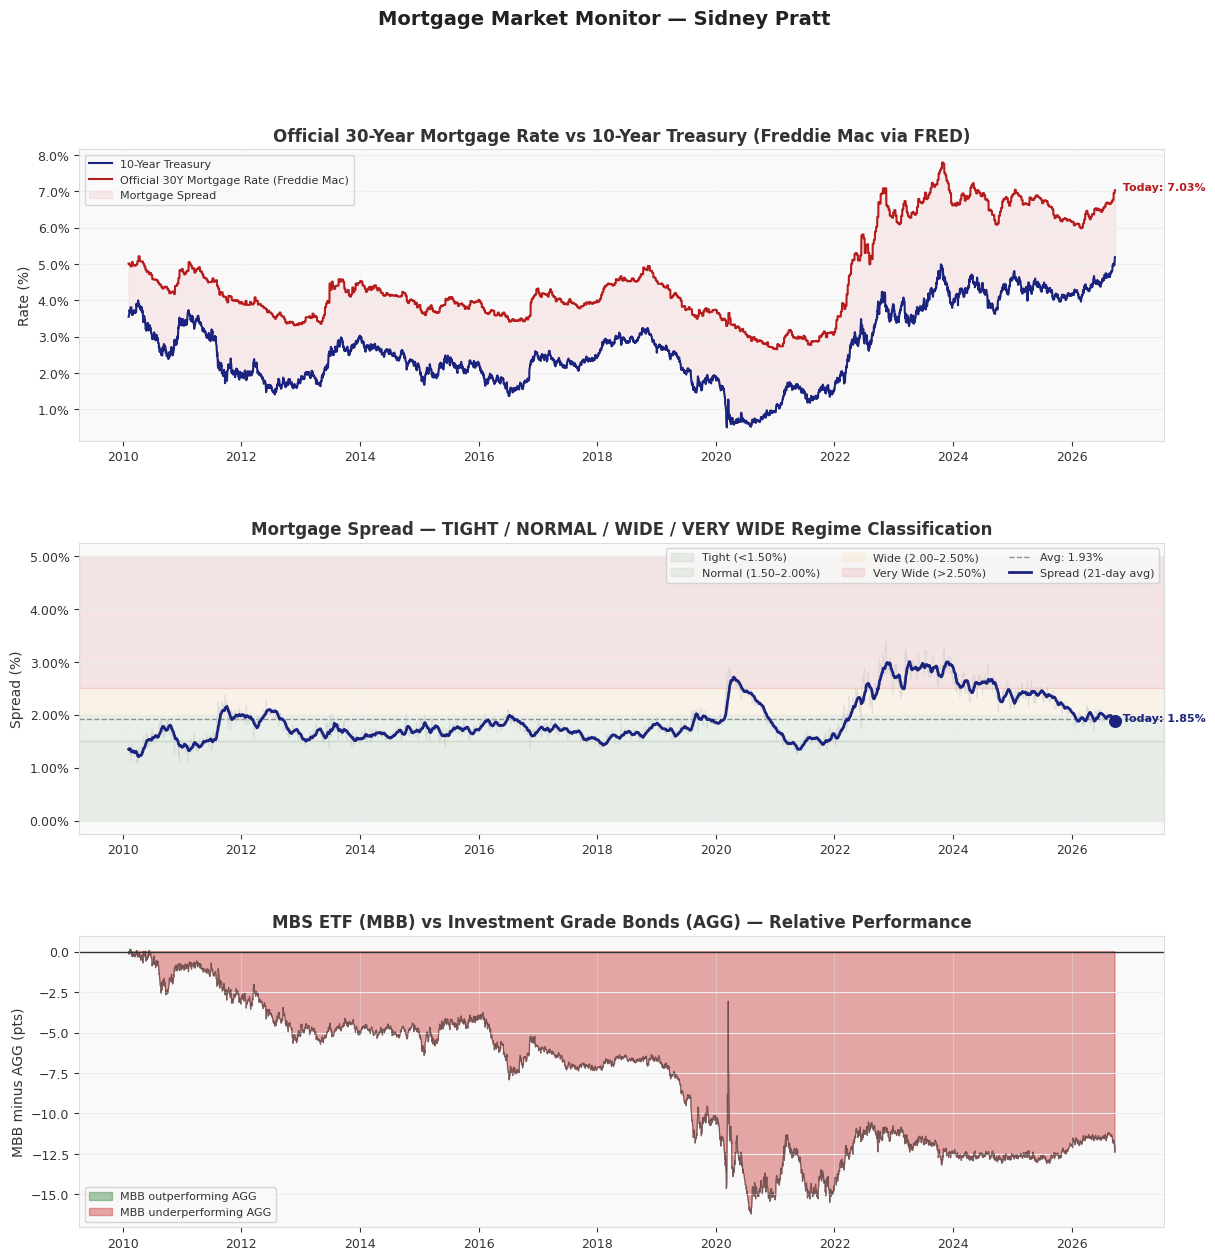

Chart saved as mortgage_monitor.png


In [11]:
fig = plt.figure(figsize=(14, 14))
fig.patch.set_facecolor("#FFFFFF")
gs   = gridspec.GridSpec(3, 1, figure=fig, hspace=0.35)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

for ax in axes:
    ax.set_facecolor("#F9F9F9")
    ax.tick_params(colors="#333333", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#DDDDDD")
    ax.grid(axis="y", color="#EEEEEE", linewidth=0.8)
    ax.grid(axis="x", color="#EEEEEE", linewidth=0.5, alpha=0.5)

fig.suptitle("Mortgage Market Monitor — Sidney Pratt",
             fontsize=14, fontweight="bold", color="#222222", y=0.98)

# Chart 1 — Official mortgage rate vs 10Y Treasury
ax = axes[0]
ax.plot(df.index, df["10Y_Treasury"],
        color="#1A237E", linewidth=1.5, label="10-Year Treasury")
ax.plot(df.index, df["Mortgage_Rate"],
        color="#B71C1C", linewidth=1.5,
        label="Official 30Y Mortgage Rate (Freddie Mac)")
ax.fill_between(df.index, df["10Y_Treasury"], df["Mortgage_Rate"],
    color="#E53935", alpha=0.08, label="Mortgage Spread")
ax.set_title("Official 30-Year Mortgage Rate vs 10-Year Treasury (Freddie Mac via FRED)",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("Rate (%)", color="#333333")
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.annotate(f"  Today: {cur_mort:.2f}%",
    xy=(df.index[-1], cur_mort),
    fontsize=8, color="#B71C1C", fontweight="bold")

# Chart 2 — Mortgage spread with regime shading
ax = axes[1]
ax.axhspan(0,    1.50, color="#1B5E20", alpha=0.08, label="Tight (<1.50%)")
ax.axhspan(1.50, 2.00, color="#2E7D32", alpha=0.08, label="Normal (1.50–2.00%)")
ax.axhspan(2.00, 2.50, color="#F9A825", alpha=0.08, label="Wide (2.00–2.50%)")
ax.axhspan(2.50, 5.00, color="#C62828", alpha=0.10, label="Very Wide (>2.50%)")
ax.axhline(y=avg_spread, color="#666666", linewidth=1,
           linestyle="--", alpha=0.7, label=f"Avg: {avg_spread:.2f}%")
ax.plot(df.index, df["Mortgage_Spread"],
        color="#CCCCCC", linewidth=0.5, alpha=0.6)
ax.plot(df["Spread_Smooth"].index, df["Spread_Smooth"].values,
        color="#1A237E", linewidth=2, label="Spread (21-day avg)", zorder=4)
ax.scatter(df.index[-1], float(df["Spread_Smooth"].iloc[-1]),
           color="#1A237E", s=70, zorder=5)
ax.annotate(f"  Today: {cur_spread:.2f}%",
    xy=(df.index[-1], float(df["Spread_Smooth"].iloc[-1])),
    fontsize=8, color="#1A237E", fontweight="bold")
ax.set_title("Mortgage Spread — TIGHT / NORMAL / WIDE / VERY WIDE Regime Classification",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("Spread (%)", color="#333333")
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8, ncol=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))

# Chart 3 — MBB vs AGG relative performance
ax = axes[2]
mbb_norm = (df["MBB"] / df["MBB"].iloc[0]) * 100
agg_norm = (df["AGG"] / df["AGG"].iloc[0]) * 100
relative  = mbb_norm - agg_norm
ax.fill_between(df.index, 0, relative,
    where=relative >= 0, color="#2E7D32", alpha=0.4,
    label="MBB outperforming AGG")
ax.fill_between(df.index, 0, relative,
    where=relative <  0, color="#C62828", alpha=0.4,
    label="MBB underperforming AGG")
ax.axhline(y=0, color="#333333", linewidth=1)
ax.plot(df.index, relative, color="#333333", linewidth=0.8, alpha=0.6)
ax.set_title("MBS ETF (MBB) vs Investment Grade Bonds (AGG) — Relative Performance",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("MBB minus AGG (pts)", color="#333333")
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8)

plt.tight_layout(pad=2.5)
plt.savefig("mortgage_monitor.png", dpi=140,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Chart saved as mortgage_monitor.png")

## Cell 17 — Final Report Summary
Prints a clean final summary of all signals generated by this
notebook. This is the output a trader would read each morning
to get a quick snapshot of the mortgage market — the official
rate, the spread, the regime, the refi environment, and the
prepayment risk signal. Also confirms the data source so anyone
reviewing the notebook knows exactly where the numbers come from.

In [13]:
print("=" * 60)
print("MORTGAGE MARKET MONITOR — REPORT COMPLETE")
print("=" * 60)
print(f"Date:                    {cur_date}")
print(f"Official 30Y Mortgage:   {cur_mort:.2f}%")
print(f"10-Year Treasury:        {cur_10y:.2f}%")
print(f"30-Year Treasury:        {cur_30y:.2f}%")
print(f"Mortgage Spread:         {cur_spread:.2f}%  ({cur_spread*100:.0f} bps)")
print(f"Percentile since 2010:   {pct_rank:.0f}th")
print(f"Spread Regime:           {cur_regime}")
print(f"Refi Environment:        {cur_refi}")
print(f"Prepayment Risk:         {cur_prepay}")
print(f"MBB 1-Month:             {mbb_1m:+.1f}%")
print(f"MBB 12-Month:            {mbb_12m:+.1f}%")
print()
print(f"Data Source:             Freddie Mac Primary Mortgage Market Survey")
print(f"FRED Series:             MORTGAGE30US")
print(f"Published by:            Federal Reserve Bank of St. Louis")
print(f"Accuracy:                Matches Bloomberg terminal exactly")

MORTGAGE MARKET MONITOR — REPORT COMPLETE
Date:                    September 25, 2026
Official 30Y Mortgage:   7.03%
10-Year Treasury:        5.18%
30-Year Treasury:        5.50%
Mortgage Spread:         1.85%  (185 bps)
Percentile since 2010:   55th
Spread Regime:           NORMAL
Refi Environment:        MINIMAL REFI
Prepayment Risk:         LOW
MBB 1-Month:             -3.0%
MBB 12-Month:            -0.7%

Data Source:             Freddie Mac Primary Mortgage Market Survey
FRED Series:             MORTGAGE30US
Published by:            Federal Reserve Bank of St. Louis
Accuracy:                Matches Bloomberg terminal exactly
